# Project 1: Conjugate Priors
Sophia Klymchuk & Devin Zhang

Instructions: <br>The project is to implement conjugate estimators for the following scenarios:
- Binomial
- Gaussian with known variance (i.e. estimate the mean)
- Gaussian with known mean (i.e. estimate the variance)

You should plot the mean squared error both the ML and conjugate prior estimates, all on one plot, with a legend. For each scenario, choose 2-3 different values for the hyper parameters.

Additionally, for at least one set of hyperparameter per scenario, plot the posterior density as it changes with observations. The easy way to do this is to just plot the pdf a few times, for different #s of observations.

Stretch Goal #1: Make a movie showing the posterior converge (2 points) <br>
Stretch Goal #2: Implement the conjugate prior estimator for the unknown mean and variance case. Plot the pdf as it changes as in the first part. Note this will be a 3-Dim pdf, so use a heatmap or something similar. (3 points)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta, norm, gamma


## I. Binomial Likelihood Distribution
Likelihood:
$Bin(m|N,\mu) = \binom{N}{m} \mu^m (1-\mu)^{N-m}$

Conjugate Prior:
$Beta(\mu|a,b) = \frac{\Gamma(a+b)}{\Gamma(a)\Gamma(b)} \mu^{a-1} (1-\mu)^{b-1}$

Posterior:
$P(\mu |m,l,a,b) = \frac{\Gamma(m+a+l+b)}{\Gamma(m+a)\Gamma(l+b)} \mu^{m+a-1} (1-\mu)^{l+b-1} \quad$ where $l=N-m$

### Initiate true distribution and our three prior distributions

In [ ]:
# Form our "true" distribution from which we will sample data
true_p_theta = 0.3 # loaded coin, 30% heads
num_flips = 1000 # number of iid trials

# Three different hyperparameter cases for our prior distribution
params = [(1, 1), (10, 10), (7,3)]


### Make observations. Update our hyperparameters. Find posterior.
#### PLEASE NOTE THAT THE LIVE MOVIE DOES NOT WORK IN NOTEBOOK. WE WILL SUBMIT A SEPARATE VIDEO

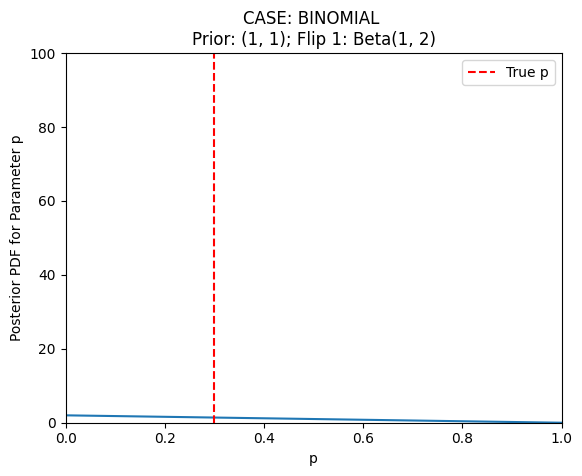

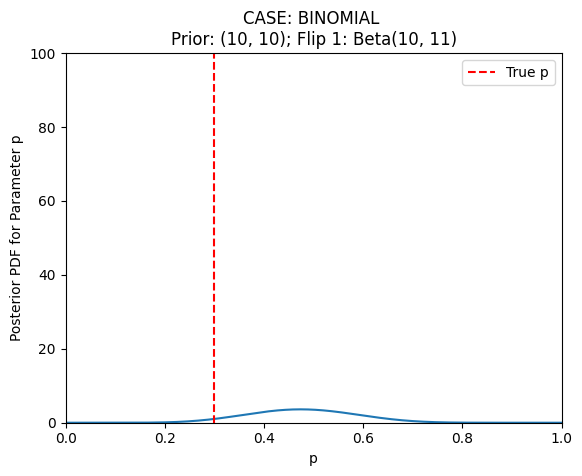

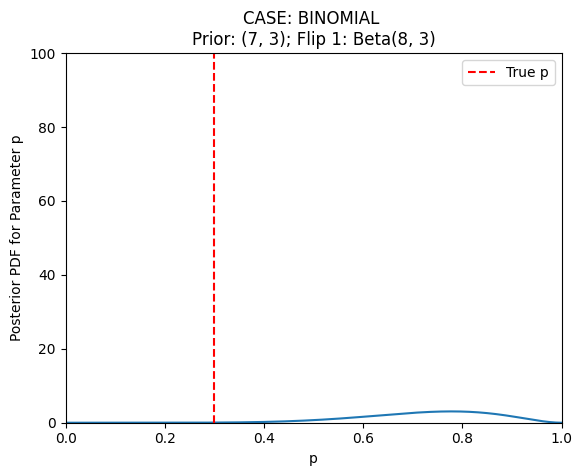

In [ ]:
results = [] #Store all of our final results (parameter estimates and MSE) for each prior

for n, (alpha_param, beta_param) in enumerate(params):
    flip_history = [] # dataset of observations
    bayesian_history = [] # bayesian parameter estimate as we increment trials
    mse_b = [] # bayesian mse as we increment trials
    frequentist_history = [] # frequentise parameter estimate as we increment trials
    mse_f=[] #frequentist mse as we increment trials

    prior = beta(alpha_param, beta_param)

    # This is our live plotting for stretch goal #1
    # PLEASE NOTE THAT IT DOES NOT WORK IN NOTEBOOK. WE WILL SUBMIT A SEPARATE VIDEO
    plt.ion()
    fig, ax = plt.subplots()
    x = np.linspace(0, 1, 1000)
    line, = ax.plot(x, prior.pdf(x))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 100)
    ax.axvline(true_p_theta, color='red', linestyle='--', label='True p')
    ax.set_xlabel('p')
    ax.set_ylabel('Posterior PDF for Parameter p')
    ax.legend()

    for i in range(num_flips):
        flip = np.random.binomial(1, true_p_theta)
        flip_history.append(flip)

        # update
        if flip == 1:
            alpha_param += 1
        else:
            beta_param += 1

        # posterior calculation utilizing updated hyperparameters
        posterior = beta(alpha_param, beta_param)
        p_theta_b = posterior.mean()
        bayesian_history.append(p_theta_b)
        mse_b.append((p_theta_b - true_p_theta)**2)

        # max likelihood
        p_theta_f = flip_history.count(1) / (i+1)
        frequentist_history.append(p_theta_f)
        mse_f.append((p_theta_f - true_p_theta)**2)

        # update plot
        line.set_ydata(posterior.pdf(x))
        ax.set_title(f'CASE: BINOMIAL \nPrior: {params[n]}; Flip {i+1}: Beta({alpha_param}, {beta_param})')
        plt.pause(0.00001)

    result = {"prior": params[n], "bayesian estimate": p_theta_b, "frequentist estimate": p_theta_f, "bayesian mse": mse_b, "frequentist mse": mse_f}
    results.append(result)


### Final results


Prior Hyperparameters: (1, 1). Final Bayesian Estimate: 0.2934. Final ML Estimate: 0.2930


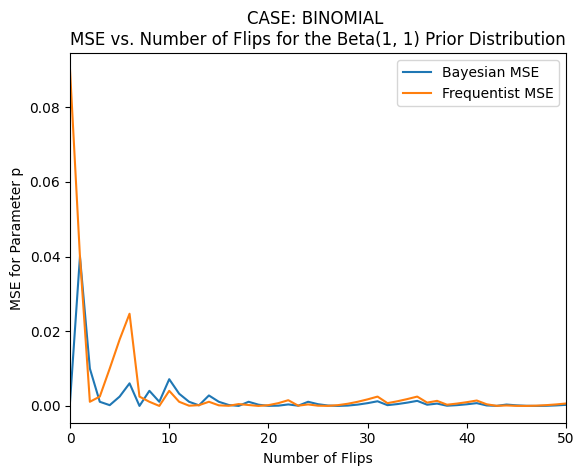


Prior Hyperparameters: (10, 10). Final Bayesian Estimate: 0.3216. Final ML Estimate: 0.3180


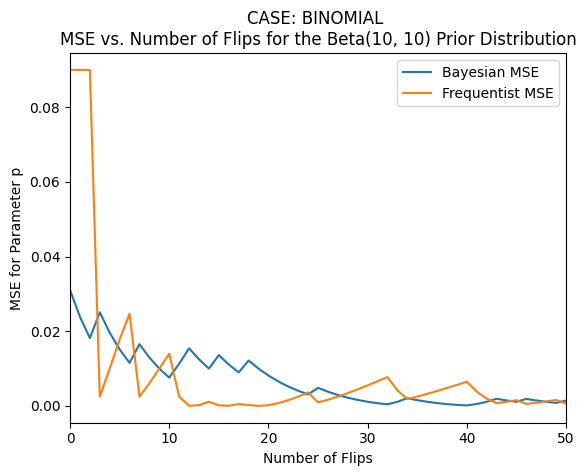


Prior Hyperparameters: (7, 3). Final Bayesian Estimate: 0.3030. Final ML Estimate: 0.2990


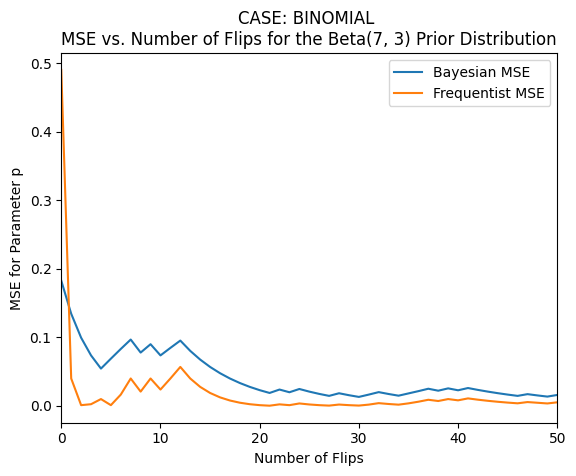

In [ ]:
for result in results:
    plt.ioff()
    plt.close()
    print(f"\nPrior Hyperparameters: {result["prior"]}. Final Bayesian Estimate: {result["bayesian estimate"]:.4f}. Final ML Estimate: {result["frequentist estimate"]:.4f}")

    plt.figure()
    plt.xlim(0, 100)
    plt.plot(result["bayesian mse"], label="Bayesian MSE")
    plt.plot(result["frequentist mse"], label="Frequentist MSE")
    plt.title(f"CASE: BINOMIAL \nMSE vs. Number of Flips for the Beta{result["prior"]} Prior Distribution" )
    plt.xlabel("Number of Flips")
    plt.ylabel("MSE for Parameter p")
    plt.legend()
    plt.show()

## II. Gaussian Likelihood Distribution with Known Variance
Likelihood:
$P(X|\mu, \sigma^2) = \frac{1}{(2\pi\sigma^2)^{N/2}} e^{-\frac{1}{2\sigma^2} \sum_{n=1}^{N}(x_n-\mu)^2}$

Prior:
$P(\mu) = N(\mu | \mu_0, \sigma_0^2)$

Posterior:
$P(\mu | X) = N(\mu | \mu_N, \sigma_N^2)$

### Initiate true distribution and our three prior distributions

In [ ]:
true_mean = 0
true_sigma = 1
true_variance = true_sigma**2
num_samples = 1000

# hyperparameters
params = [(0, 1), (0, 10), (5, 5)]

###Make observations. Update our hyperparameters. Find posterior.
#### PLEASE NOTE THAT THE LIVE MOVIE DOES NOT WORK IN NOTEBOOK. WE WILL SUBMIT A SEPARATE VIDEO

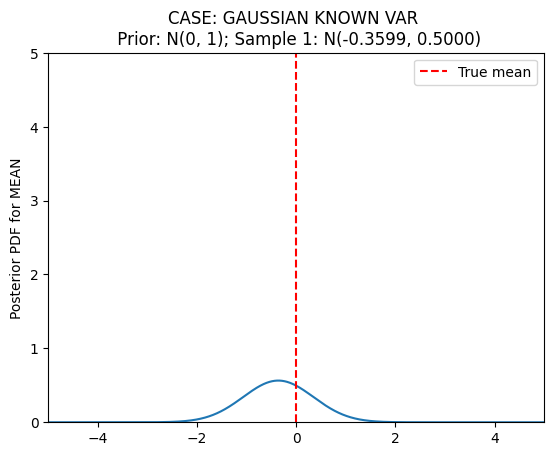

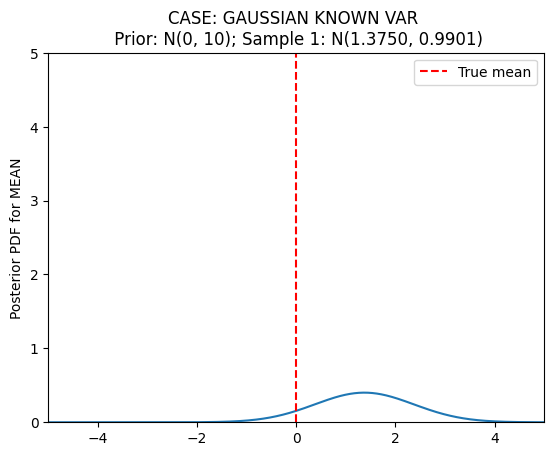

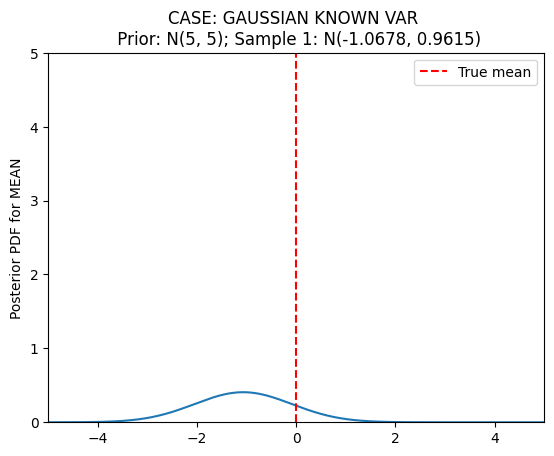

In [ ]:
results = [] #Store all of our final results (parameter estimates and MSE) for each prior

for n, (mean_param, tau_param) in enumerate(params):
    sample_history = []
    bayesian_history = []
    mse_b = []
    frequentist_history = []
    mse_f=[]

    mu_posterior = mean_param
    tau_posterior_squared = tau_param**2

    # live plot
    plt.ion()
    fig, ax = plt.subplots()
    x = np.linspace(-5, 5, 1000)
    line, = ax.plot(x, norm(mean_param, tau_param).pdf(x))
    ax.set_xlim(-5, 5)
    ax.set_ylim(0, 5)
    ax.axvline(true_mean, color='red', linestyle='--', label='True mean')
    ax.set_ylabel('Posterior PDF for MEAN')
    ax.legend()

    for i in range(num_samples):
        sample = np.random.normal(true_mean, true_sigma)
        sample_history.append(sample)

        # update
        tau_new_squared = 1 / (1/tau_posterior_squared + 1/true_variance) # new precision = old precision + data precision
        mu_new = (mu_posterior/tau_posterior_squared + sample/true_variance) / (1/tau_posterior_squared + 1/true_variance)  # new mean = (old estimate * old precision + new data * data precision)/total precision

        mu_posterior = mu_new
        tau_posterior_squared = tau_new_squared
        tau_posterior = np.sqrt(tau_posterior_squared)

         # posterior
        posterior = norm(mu_posterior, tau_posterior)
        bayesian_estimate = mu_posterior
        bayesian_history.append(bayesian_estimate)

        # ML estimate
        ml_estimate = np.mean(sample_history)
        frequentist_history.append(ml_estimate)

        # MSE
        mse_b.append((bayesian_estimate - true_mean)**2)
        mse_f.append((ml_estimate - true_mean)**2)

        # update plot
        line.set_ydata(posterior.pdf(x))
        ax.set_title(f'CASE: GAUSSIAN KNOWN VAR \n Prior: N{params[n]}; Sample {i+1}: N({mu_posterior:.4f}, {tau_posterior_squared:.4f})')
        plt.pause(0.00001)

    result = {"prior": params[n], "bayesian estimate": bayesian_estimate, "frequentist estimate": ml_estimate, "bayesian mse": mse_b, "frequentist mse": mse_f}
    results.append(result)

### Final results


Prior Hyperparameters: (0, 1). Final Bayesian Estimate: -0.0194. Final ML Estimate: -0.0194


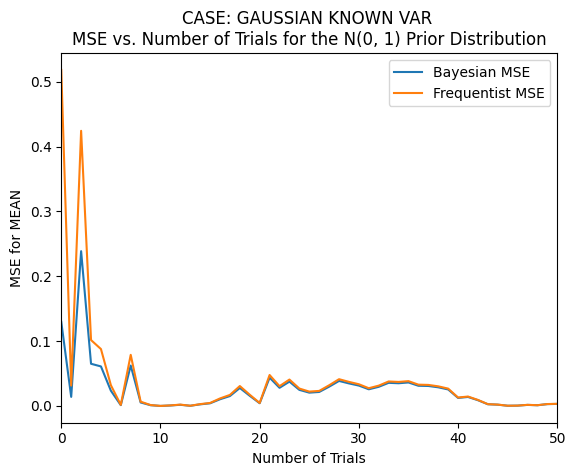


Prior Hyperparameters: (0, 10). Final Bayesian Estimate: 0.0563. Final ML Estimate: 0.0563


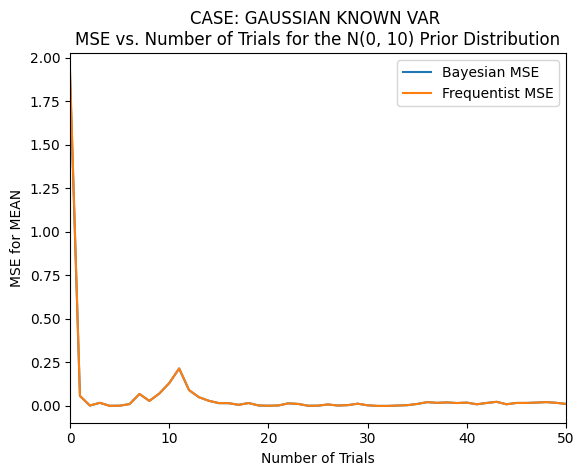


Prior Hyperparameters: (5, 5). Final Bayesian Estimate: -0.0234. Final ML Estimate: -0.0236


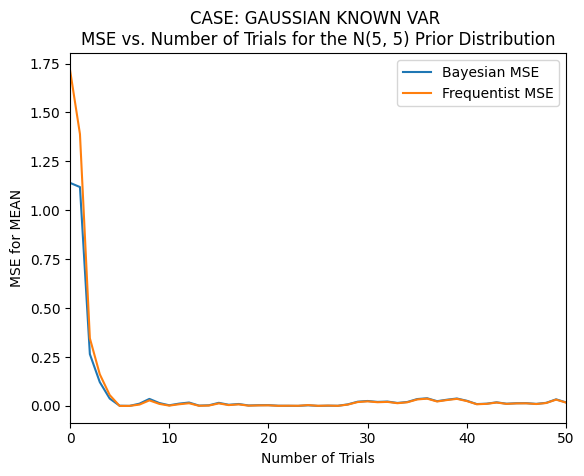

In [ ]:
for result in results:
    plt.ioff()
    plt.close()
    print(f"\nPrior Hyperparameters: {result["prior"]}. Final Bayesian Estimate: {result["bayesian estimate"]:.4f}. Final ML Estimate: {result["frequentist estimate"]:.4f}")

    plt.figure()
    plt.xlim(0, 100)
    plt.plot(result["bayesian mse"], label="Bayesian MSE")
    plt.plot(result["frequentist mse"], label="Frequentist MSE")
    plt.title(f"CASE: GAUSSIAN KNOWN VAR \nMSE vs. Number of Trials for the N{result["prior"]} Prior Distribution" )
    plt.xlabel("Number of Trials")
    plt.ylabel("MSE for MEAN")
    plt.legend()
    plt.show()

## III. Gaussian Likelihood Distribution with Known Mean
Likelihood:
$P(X|\mu, \sigma^2) = \frac{1}{(2\pi\sigma^2)^{N/2}} e^{-\frac{1}{2\sigma^2} \sum_{n=1}^{N}(x_n-\mu)^2}$

DEF. Precision: $\lambda = \frac{1}{\sigma^2}$

Prior:
$Gam(\lambda | a, b) = \frac{1}{\Gamma (a)} b^a \lambda^{a-1} e^{-b \lambda}$

Posterior:
$P(\lambda | X) = Gam(\lambda | a_N, b_N)\quad$ where $a_N = a_0 + \frac{N}{2}; \quad b_N = b_0 + \frac{1}{2} \sum_{n=1}^{N} (x_n - \mu)^2$

### Initiate true distribution and our three prior distributions

In [ ]:
true_mean = 0
true_sigma = 1
true_variance = true_sigma**2
true_precision = 1/true_variance
num_samples = 1000

# hyperparameters
params = [(0.1, 0.1), (1, 1), (4, 6)]

###Make observations. Update our hyperparameters. Find posterior.
#### PLEASE NOTE THAT THE LIVE MOVIE DOES NOT WORK IN NOTEBOOK. WE WILL SUBMIT A SEPARATE VIDEO

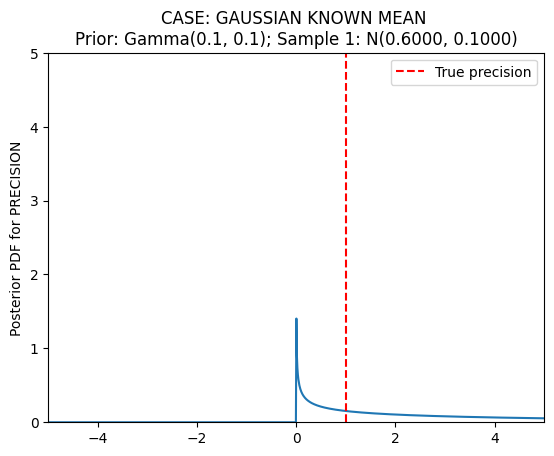

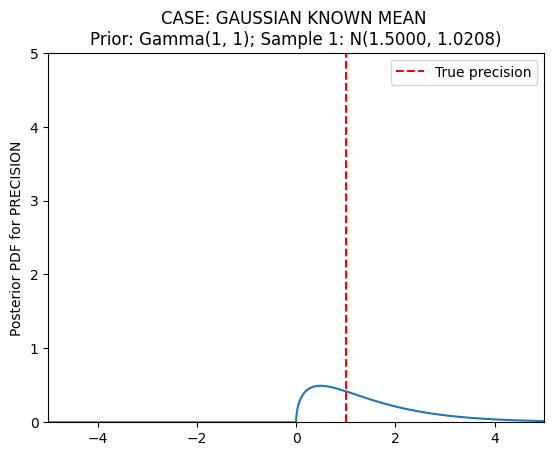

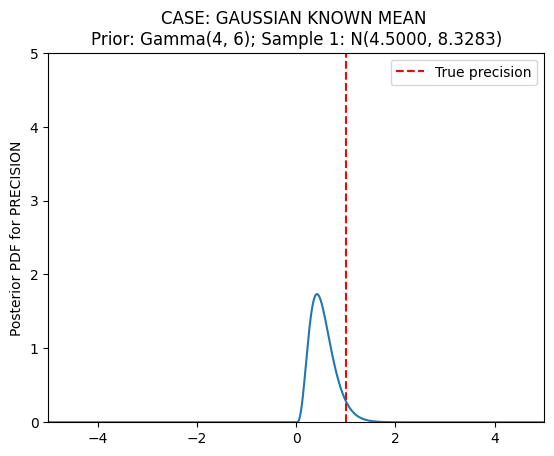

In [ ]:
results = [] #Store all of our final results (parameter estimates and MSE) for each prior

for n, (a_param, b_param) in enumerate(params):
    sample_history = []
    bayesian_history = []
    mse_b = []
    frequentist_history = []
    mse_f=[]

    # live plot
    plt.ion()
    fig, ax = plt.subplots()
    x = np.linspace(-5, 5, 1000)
    line, = ax.plot(x, gamma.pdf(x=x, a = a_param, scale=1/b_param))
    ax.set_xlim(-5, 5)
    ax.set_ylim(0, 5)
    ax.axvline(true_precision, color='red', linestyle='--', label='True precision')
    ax.set_ylabel('Posterior PDF for PRECISION')
    ax.legend()

    a_param_new = a_param
    b_param_new = b_param

    for i in range(num_samples):
        sample = np.random.normal(true_mean, true_sigma)
        sample_history.append(sample)

        # update
        a_param_new = a_param_new + 0.5 # add N/2, but N=1 because we increment by 1 sample only
        b_param_new = b_param_new + 0.5 * (sample - true_mean)**2

        a_posterior = a_param_new
        b_posterior = b_param_new

         # posterior
        posterior = gamma(a=a_posterior, scale=1/b_posterior)
        bayesian_estimate = b_posterior / a_posterior # I did 1 / the normal estimate. so we are getting variance not precision.
        bayesian_history.append(bayesian_estimate)

        # ML estimate
        ml_estimate = np.var(sample_history)
        frequentist_history.append(ml_estimate)

        # MSE
        # note we chose to plot variance not precision since precision sometimes would get big with its 1/var term...
        # not a pretty or well-scaled or informtive plot.
        mse_b.append((bayesian_estimate - true_variance)**2)
        mse_f.append((ml_estimate - true_variance)**2)

        # update plot
        line.set_ydata(posterior.pdf(x))
        ax.set_title(f'CASE: GAUSSIAN KNOWN MEAN \nPrior: Gamma{params[n]}; Sample {i+1}: N({a_posterior:.4f}, {b_posterior:.4f})')
        plt.pause(0.00001)

    result = {"prior": params[n], "bayesian estimate": bayesian_estimate, "frequentist estimate": ml_estimate, "bayesian mse": mse_b, "frequentist mse": mse_f}
    results.append(result)

### Final results


Prior Hyperparameters: (0.1, 0.1). Final Bayesian Estimate: 1.0045. Final ML Estimate: 1.0041


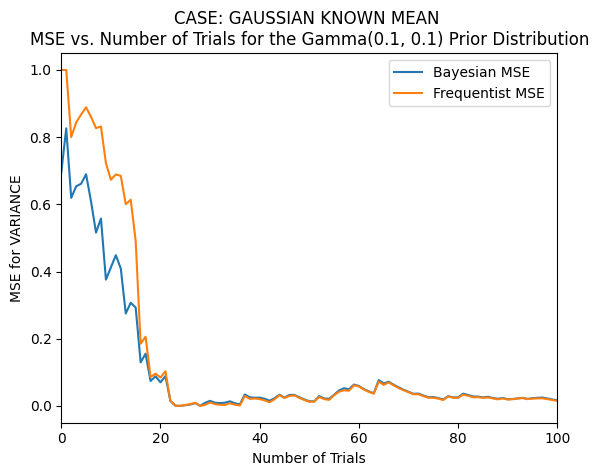


Prior Hyperparameters: (1, 1). Final Bayesian Estimate: 0.9309. Final ML Estimate: 0.9292


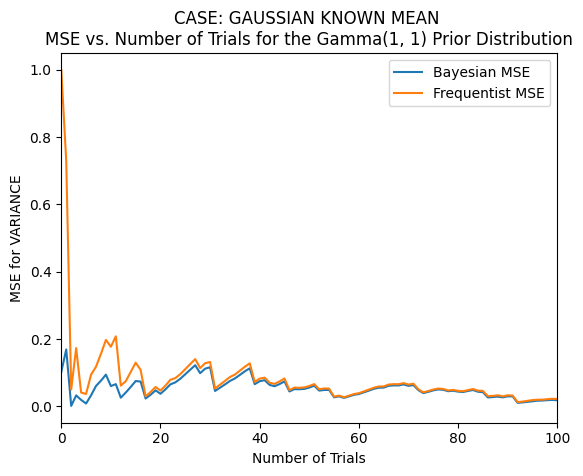


Prior Hyperparameters: (4, 6). Final Bayesian Estimate: 1.0092. Final ML Estimate: 0.9977


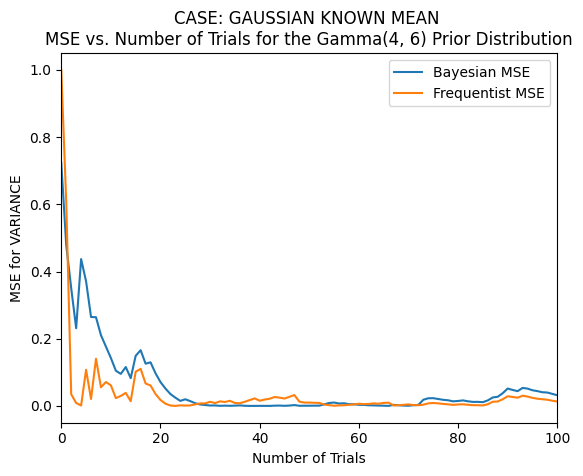

In [ ]:
for result in results:
    plt.ioff()
    plt.close()
    print(f"\nPrior Hyperparameters: {result["prior"]}. Final Bayesian Estimate: {result["bayesian estimate"]:.4f}. Final ML Estimate: {result["frequentist estimate"]:.4f}")

    plt.figure()
    plt.xlim(0, 100)
    #plt.ylim(0, 5)
    plt.plot(result["bayesian mse"], label="Bayesian MSE")
    plt.plot(result["frequentist mse"], label="Frequentist MSE")
    plt.title(f"CASE: GAUSSIAN KNOWN MEAN \nMSE vs. Number of Trials for the Gamma{result["prior"]} Prior Distribution" )
    plt.xlabel("Number of Trials")
    plt.ylabel("MSE for VARIANCE")
    plt.legend()
    plt.show()